In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt tham số đồ họa
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# 1. Đọc dữ liệu (Lưu ý: Thay đổi đường dẫn cho phù hợp với Drive của bạn)
# DATA_PATH = '/content/drive/MyDrive/DataVisLab2/dataset.csv'
DATA_PATH = 'data3/dataset.csv'
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

## Analysis Objective 1: Evaluating the correlation between Educational attainment and the Female labor force

### 1.1. Analysis Objectives

To measure the degree of **correlation** between **the female tertiary education enrollment rate** and **the female labor force participation rate on a global scale in the year 2020**. Our group chose 2020 because it is the recent milestone with available data for **many countries** in this regard.

This objective is set to track **how the rate of women appearing in the labor force changes as more women achieve higher education**.

### 1.2. Data Fields Used

**`SE.TER.ENRR.FE` - School enrollment, tertiary, female (% gross)**
* This indicator measures the ratio of total female students enrolled in tertiary education (universities, colleges, post-secondary certificates), regardless of age, to the female population of the age group that officially corresponds to the tertiary level of education (usually the 18-22 age group). Data is provided by the *UNESCO Institute for Statistics (UIS)*.
* Calculation method: **[Total female students enrolled in Tertiary education of all ages] / [Total female population in the official Tertiary school-age group] * 100**
* This indicator reflects the training capacity and higher-knowledge access level of a country's female workforce.
* **Note:** Because this is a **gross ratio**, the numerator includes students of any age (including late enrollees or second-degree seekers), while the denominator is fixed to a specific age group. Therefore, this ratio can absolutely **exceed 100%** in developed countries.

**`SL.TLF.CACT.FE.ZS` - Labor force participation rate, female (% of female population ages 15+)**
* This indicator measures the proportion of women aged 15 and older who are economically active (supplying labor for the production of goods and services during a specified period). Data is an estimated model provided by the *International Labour Organization (ILO)*.
* Calculation method: **([Number of employed women] + [Number of unemployed women actively looking for work]) / [Total female population aged 15 and older] * 100**
* This indicator reflects the extent to which women directly participate in and contribute to the market economy rather than being confined to the domestic household economy.
* **Note:** The concept of "Labor Force" includes those actively seeking work, but **strictly excludes** women doing full-time homemaking (unpaid, informal work).

In [3]:
# === QUESTION 3: CORRELATION BETWEEN EDUCATION (TERTIARY) AND FEMALE EMPLOYMENT ===

# 1. Declare the list of necessary indicators
INDICATORS_Q3 = {
    'SE.TER.ENRR.FE': 'Female_Tertiary_Edu',
    'SL.TLF.CACT.FE.ZS': 'Female_Labor_Force'
}

# 2. Filter data from df_raw for 2020
TARGET_YEAR_Q3 = '2020 [YR2020]'

corr_df3 = df_raw[df_raw['Series Code'].isin(INDICATORS_Q3.keys())].copy()

# 3. Keep important columns and rename
corr_df3 = corr_df3[['Country Name', 'Country Code', 'Series Code', TARGET_YEAR_Q3]]
corr_df3.rename(columns={TARGET_YEAR_Q3: 'Value'}, inplace=True)

# Convert data types (from string to float, assign NaN to '..' values)
corr_df3['Value'] = pd.to_numeric(corr_df3['Value'], errors='coerce')

# 4. Transform table structure (Pivot from Long to Wide)
pivot_df3 = corr_df3.pivot(index=['Country Name', 'Country Code'], 
                           columns='Series Code', 
                           values='Value').reset_index()

# Rename Series Codes to understandable names
pivot_df3.rename(columns=INDICATORS_Q3, inplace=True)

# 5. Missing Data Cleansing
# Drop countries missing either of the 2 indicators
corr_clean3 = pivot_df3.dropna(subset=['Female_Tertiary_Edu', 'Female_Labor_Force']).copy()

print(f"Number of countries with complete data for both indicators in 2020: {len(corr_clean3)} countries")
corr_clean3.head()

ValueError: Index contains duplicate entries, cannot reshape

### 1.3. Detailed Analysis

**Chart type:** Scatter plot combined with a regression trendline.

**Reason for choosing this chart**: To examine the correlation between two quantitative variables (Tertiary enrollment rate vs. Labor force participation rate) that we have the data of **87 countries for the year 2020**, our group will use a **Scatter plot** for the most intuitive and accurate representation. This chart not only helps us see the general trend (via the regression line) but also makes it easy to spot outliers - meaning countries that defy standard norms.

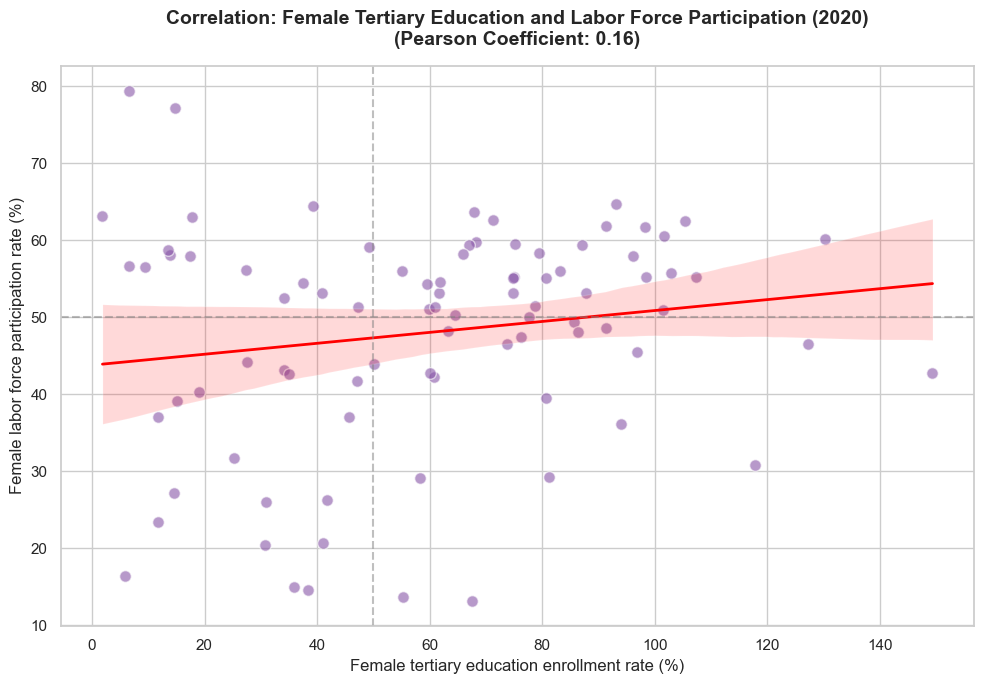

In [49]:
# === CHART 3: SCATTER PLOT & REGRESSION LINE ===
plt.figure(figsize=(10, 7))

# Calculate Pearson correlation coefficient
corr_edu_labor = corr_clean3['Female_Tertiary_Edu'].corr(corr_clean3['Female_Labor_Force'])

# Draw scatter plot with regression line
sns.regplot(data=corr_clean3, x='Female_Tertiary_Edu', y='Female_Labor_Force', 
            scatter_kws={'alpha':0.6, 'color':'#8856a7', 'edgecolor':'w', 's':70}, 
            line_kws={'color':'red', 'linewidth':2})

# Chart decorations
plt.title(f'Correlation: Female Tertiary Education and Labor Force Participation (2020)\n(Pearson Coefficient: {corr_edu_labor:.2f})', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Female tertiary education enrollment rate (%)', fontsize=12)
plt.ylabel('Female labor force participation rate (%)', fontsize=12)

# Add reference lines to divide quadrants
plt.axvline(50, color='gray', linestyle='--', alpha=0.5) # 50% university mark
plt.axhline(50, color='gray', linestyle='--', alpha=0.5) # 50% working mark

plt.tight_layout()
plt.show()

Based on the scatter plot above, our group deduces the following analyses:
* With a Pearson coefficient reaching only 0.16, the regression trendline (red) runs almost horizontally, indicating an **extremely weak correlation**. Data dots are chaotically spread across the entire graph rather than hugging the trendline. This partly proves a truth: **A high rate of women enrolling in tertiary education does not mean they will participate more in the labor force**.
* Using the 2 gray dashed reference lines (the 50% marks), the chart displays a clear division into **4 quadrants**, featuring the following notable points:
    * **Top-left quadrant**: There is a large number of countries with **very low female tertiary enrollment (only 10-30%) but skyrocketing labor participation rates (60-80%)**. These are predominantly agricultural or low-income economies where women are forced into manual labor to survive, even without degrees.
    * **Bottom-right quadrant**: This is the most remarkable area. Many countries boast **extremely high female tertiary enrollment (60%, 80%, even exceeding 100%) but their working rate falls below 40%, sometimes even dropping to 15-20%**. This indicates that women in these nations have excellent access to knowledge but face some barrier preventing them from stepping out to work.
    * **Top-right quadrant (the ideal scenario)**: There remains a cluster of countries that **satisfy both factors (over 50% studying and over 50% working)**. These are usually developed countries with robust social welfare systems.

### 1.4. General Comments and Limitations

**1.4.1. General Comments**

This chart has exposed a global **educational paradox** regarding women: *A university degree is a necessary condition to elevate human capital quality, but it is absolutely **not sufficient** to liberate female labor.*

The data shows that in many countries, even though the education system is extremely open (female tertiary students dominate), upon graduation, they vanish from the labor market. It is highly likely that barriers such as patriarchy, religious prejudices, lack of childcare facilities, or economies failing to create enough suitable jobs... have shackled these highly educated women. This represents a massive waste of human capital for the economy.

**1.4.2. Limitations of the Analysis**

Although the chart successfully reflects certain paradox, this analysis still faces a few hurdles regarding data specification:

* The `SL.TLF.CACT.FE.ZS` indicator on the Y-axis includes all forms of labor: from corporate CEOs to freelancers, street vendors, and subsistence agriculture workers. Therefore, in poor countries, the fact that women have a very high working rate (top-left of the chart) does not mean they have good jobs or high gender equality; it's simply the force of economic circumstances. **This creates significant noise when compared to the proportion holding university degrees.**
* The X-axis features countries **exceeding the 100% mark** (some even reaching up to 140%). This is a characteristic of the **gross enrollment ratio** (which counts older women returning to study, second-degree seekers, and late enrollees). **This causes the data to not 100% accurately reflect the proportion of college-age female youth currently in higher education.**

## Analysis Objective 2: Assessing the proportion of parliamentary seats held by women in countries around the world.

### 2.1. Analysis Objectives

To assess **the overall picture of the distribution of parliamentary seats held by women globally in 2020** (our group chose 2020 because it is the recent milestone with available data for **many countries** in this regard), while comparing the trends of this indicator in six representative countries across continents (Rwanda, Sweden, the United States, Vietnam, Japan, and Nigeria) between 2000 and 2024.

Combining a spatial perspective (global map) and a temporal perspective (24-year trends) will provide the most comprehensive assessment of women's participation in politics worldwide, and in the countries whose trends are examined.

### 2.2. Data Fields Used

**`SG.GEN.PARL.ZS` - Proportion of seats held by women in national parliaments (%)**
* This indicator measures the percentage of seats held by women in a single-chamber parliament or the lower chamber of a bicameral parliament. For example, in Vietnam, it represents the percentage of female members in the Vietnam National Assembly. Data is provided by the *Inter-Parliamentary Union (IPU)*.
* Calculation method: **[Total seats held by women in the Lower Chamber/Parliament] / [Total seats in the Lower Chamber/Parliament] * 100**
* This indicator reflects the level of women's political participation in different countries.
* **Note:** This indicator **does not** include seats in the Upper house or local governments.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # Import thêm thư viện vẽ bản đồ

# Cài đặt tham số đồ họa
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# 1. Đọc dữ liệu
DATA_PATH = 'data3/dataset.csv' # Nhớ đổi lại đường dẫn nếu cần
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# 2. Xử lý dữ liệu định dạng Wide to Long cho toàn cầu
year_cols =[c for c in df_raw.columns if c.startswith('20') and c.endswith(']')]
parl_all = df_raw[df_raw['Series Code'] == 'SG.GEN.PARL.ZS'].copy()

parl_long = parl_all.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw', value_name='Value'
)
parl_long['Year'] = parl_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
parl_long['Value'] = pd.to_numeric(parl_long['Value'], errors='coerce')

# 3. Lọc riêng dữ liệu cho 6 quốc gia Case Study (Line Chart)
SELECTED_COUNTRIES = ['RWA', 'NGA', 'SWE', 'USA', 'VNM', 'JPN']
parl_case_study = parl_long[(parl_long['Country Code'].isin(SELECTED_COUNTRIES)) & (parl_long['Year'] <= 2024)].copy()

### 2.3. Detailed Analysis

**Chart 1: Choropleth map**

**Reason for choosing this chart:** To get a comprehensive view of the geographical distribution of female parliamentarians worldwide, the **choropleth map** is the appropriate choice. This chart allows viewers to immediately identify leading regions (bold colors) and lagging regions (light colors) through color intensity, thereby revealing the differentiation between continents.

In [51]:
# === BIỂU ĐỒ 1: CHOROPLETH MAP ===
# Lọc dữ liệu năm 2020 để vẽ bản đồ (Năm gần nhất có độ phủ dữ liệu toàn cầu tốt nhất)
df_map = parl_long[parl_long['Year'] == 2020].dropna(subset=['Value'])

fig = px.choropleth(
    df_map, 
    locations="Country Code", 
    color="Value", 
    hover_name="Country Name",
    color_continuous_scale="Reds", 
    title="Heatmap by country: Percentage of parliamentary seats held by women (2020)"
)

fig.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0},
    coloraxis_colorbar=dict(title="value"),
    geo=dict(
        showland=True,
        landcolor="lightgray"  
    )
)

fig.show()

Based on the color tones on the map, we can observe a certain differentiation globally:
* **Leading regions (Dark red - over 40%)**: Most notably, Latin America (Mexico, Argentina, Cuba, Nicaragua), Northern Europe (Sweden, Norway, Finland), and a few countries in Sub-Saharan Africa (Rwanda, South Africa) are dominant. These are bright spots in the world in empowering women.

* **Lagging regions (White/light - under 20%)**: Densely concentrated, forming a belt extending from the Middle East and North Africa to most of East Asia and South Asia.

* **Note that**: Gray regions represent countries without data, as our group only collected data for 100 representative countries.

**Chart 2: Line chart, color-coded by country**

**Reason for choosing this chart:** After examining the overall spatial picture, we used a **multi-line chart** to go into the detail. This chart helps compare the rate of change (slope) over 24 years for six representative countries across different continents.

In [52]:
parl_clean = parl_case_study.copy()
parl_with_data = parl_clean.dropna(subset=['Value']).copy()

print(f"Number of valid values: {len(parl_with_data)}")
print(f"Years with data: {sorted(parl_with_data['Year'].unique())}")
print(f"Number of missing values (years/countries): {parl_clean['Value'].isna().sum()}")

Number of valid values: 149
Years with data: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Number of missing values (years/countries): 1


In [53]:
# find missing values 
parl_clean[parl_clean['Value'].isna()]

,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year
106,United States,USA,Proportion of seats held by women in national ...,SG.GEN.PARL.ZS,2000 [YR2000],NaN,2000


Since the data is missing only 1 value belonging to the USA in the first year of our observation period, our group will leave that cell empty without applying any further data imputation.

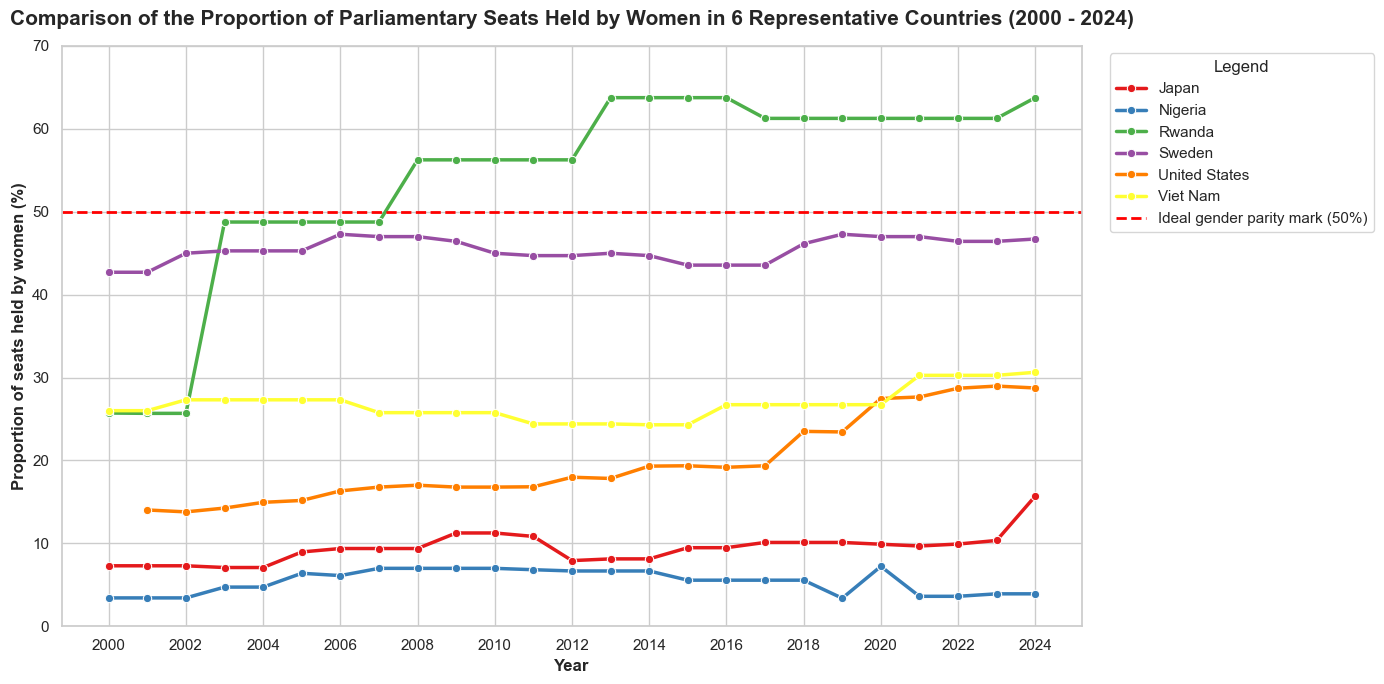

In [54]:
# === CHART 1: LINE CHART ===
plt.figure(figsize=(14, 7))

# Draw line chart
sns.lineplot(
    data=parl_clean,
    x='Year', y='Value',
    hue='Country Name',
    marker='o', markersize=6,
    palette='Set1', # Use Set1 for strong color contrast
    linewidth=2.5
)

# Add reference line for the 50% mark
plt.axhline(50, color='red', linestyle='--', linewidth=2, label='Ideal gender parity mark (50%)')

# Chart decorations
plt.title('Comparison of the Proportion of Parliamentary Seats Held by Women in 6 Representative Countries (2000 - 2024)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Proportion of seats held by women (%)', fontsize=12, fontweight='bold')

# Show even years on X-axis for better readability
plt.xticks(range(2000, 2025, 2))
plt.ylim(0, 70) # Expand Y-axis to avoid crowding the edges

# Custom Legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Legend', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

Based on the chart above, our group has drawn several analytical points regarding the 6 countries:

* **Rwanda's line is the most remarkable feature of the entire chart.** Starting at over 25% in 2000, Rwanda experienced a vertical leap approaching 50% in 2003, and continued to break through to the highest level in the world (over 60%) from 2013 to the present. Rwanda is the only country in the group to surpass the ideal 50% mark (the red dashed line). The core reason is that the country's new Constitution in 2003 mandated a strict "gender quota" policy of a minimum of 30% for women, transforming a poor African nation into a global leader in female legislative representation [[reference](https://www.sdg16.plus/policies/rwandas-30-percent-gender-quota-led-to-the-worlds-largest-share-of-women-in-government/)].

* **Sweden's line fluctuates steadily at a very high level (45% - 47%) throughout the 24 years.** This partially demonstrates that the cultural foundation of gender equality in this country is quite ideal.

* **Vietnam maintains a very good rate**, remaining stable around 26%-27% for a long time and showing a sharp upward trend past the 30% mark starting in 2021. Notably, Vietnam outperformed a superpower like the USA for two entire decades (from 2000 to 2024) and has only been approached recently. This reflects the practical effectiveness of female cadre planning in Vietnam.

* Despite being a Western democratic superpower, **the USA had a very low starting point (only about 14% in 2001)**. However, the trend line shows that the USA has the best and most stable growth rate (slope), advancing continuously to reach approximately 29% in 2024. Nevertheless, this figure is still far from the 50% parity benchmark.

* **Japan's trend line lies at the bottom area of the chart, moving almost horizontally below the 11% mark for over 20 years.** Despite a slight spike to about 15% in 2024, the chart illustrates that the level of women's participation in the legislature is severely misaligned with the country's outstanding economic development.

* **Nigeria's trend line consistently remains the lowest among all countries (fluctuating only between roughly 3% and 7%).** More concerningly, the chart shows no upward trend; instead, it continuously fluctuates, even dropping to rock bottom (under 5%) in 2024.

### 2.4. General Comments and Limitations

**2.4.1. General Comments**

The charts above shows that **economic wealth does not automatically translate to political power for women**.

* The USA and Japan are economic superpowers but lag behind or take a very long time to improve this indicator.
* Conversely, a developing nation like Vietnam maintains a high rate thanks to effective interventions from its political institutional structure.
* However, Nigeria's case also shows: Not every developing country succeeds in this aspect.
* Intervening through legal frameworks (specifically the gender quota law as applied by Rwanda) is a "shortcut" to immediately establish a balance of power and break traditional biases.

We can partially conclude that *gender equality in politics does not depend on a country's GDP scale*.

**2.4.2. Limitations of the Analysis**

* The World Bank's `SG.GEN.PARL.ZS` indicator **only calculates the percentage of seats in the Lower House or a Single-chamber Parliament**. It completely omits the Upper House, core executive positions (President, Prime Minister, Ministers), and local governments (grassroots People's Councils). Therefore, this percentage does not comprehensively reflect 100% of women's actual political power. A country might have many female parliamentarians but zero female ministers.
* The number of seats reserved for women in parliament **cannot accurately represent their actual power in the country**.
* The countries examined above **cannot represent their entire respective regions** (for instance, Rwanda and Nigeria are both in Africa but show completely contrasting data). The conclusions drawn serve as specific reference points rather than universal rules for all countries.
* Although we can see Rwanda successfully applied gender quotas to become the country with the highest proportion of women in Parliament worldwide, *has the issue of gender discrimination in this country truly been fully resolved? Or is this just scratching the surface?* If you want to explore further, you can refer to [this article](https://www.npr.org/sections/goatsandsoda/2016/07/29/487360094/invisibilia-no-one-thought-this-all-womans-debate-team-could-crush-it).


## Analysis Objective 3: Evaluating the correlation between the Proportion of female parliamentarians and Investments in education and healthcare

### 3.1. Analysis Objectives

To measure and analyze the degree of **correlation** between the **Proportion of parliamentary seats held by women** and the **Proportion of government expenditure on health and education (% of GDP)** on a **global scale** in the year **2020**. Our group chose 2020 because it is the most recent milestone with available data for **many countries** in this regard.

This objective is set to test the hypothesis: *"Do countries with higher female political participation tend to prioritize their budgets better for social welfare policies (human development)?"*

### 3.2. Data Fields Used

**`SG.GEN.PARL.ZS` - Proportion of seats held by women in national parliaments (%)**

(Described previously)

**`SE.XPD.TOTL.GD.ZS` - Government expenditure on education, total (% of GDP)**
* This indicator measures the total general government expenditure on education, expressed as a percentage of the Gross Domestic Product (GDP). Data is provided by the *UNESCO Institute for Statistics (UIS)*.
* Calculation method: **[Total public expenditure on education across all levels] / [Gross Domestic Product (GDP)] * 100**
* This indicator reflects a government's level of commitment and priority towards developing education and human capital relative to the size of its economy.
* **Note:** This indicator only calculates **public expenditure** (state tax budget); it entirely excludes private expenditure (tuition fees paid directly by households for their children).

**`SH.XPD.GHED.GD.ZS` - Domestic general government health expenditure (% of GDP)**
* This indicator measures the share of public health budget derived from domestic general government revenues (taxes, fees) relative to the size of the economy (GDP). Data is provided by the *World Health Organization (WHO)*.
* Calculation method: **[Total government health expenditure from domestic revenues] / [Gross Domestic Product (GDP)] * 100**
* This indicator reflects a country's priority level and financial autonomy in ensuring basic health security for its citizens.
* **Note:** The word "Domestic" implies the exclusion of health aid funding from foreign sources or international organizations.

In [8]:
# === QUESTION 2: CORRELATION BETWEEN FEMALE PARLIAMENTARIANS AND HEALTH/EDU INVESTMENTS ===

# 1. Declare the list of necessary indicators
INDICATORS = {
    'SG.GEN.PARL.ZS': 'Women_in_Parliament',
    'SE.XPD.TOTL.GD.ZS': 'Edu_Expenditure',
    'SH.XPD.GHED.GD.ZS': 'Health_Expenditure'
}

# 2. Filter data from df_raw (Global data, not limited to 5 countries)
# We choose 2020 as the analysis year because public spending data often has a reporting lag
TARGET_YEAR = '2020 [YR2020]'

corr_df = df_raw[df_raw['Series Code'].isin(INDICATORS.keys())].copy()

# 3. Keep important columns and rename the 2020 column to 'Value'
corr_df = corr_df[['Country Name', 'Country Code', 'Series Code', TARGET_YEAR]]
corr_df.rename(columns={TARGET_YEAR: 'Value'}, inplace=True)

# Convert data types (from string to float, assign NaN to '..' values)
corr_df['Value'] = pd.to_numeric(corr_df['Value'], errors='coerce')

# 4. Transform table structure (Pivot from Long to Wide) to calculate correlation
# Each country is 1 row, 3 indicators are 3 columns
pivot_df = corr_df.pivot(index=['Country Name', 'Country Code'], 
                         columns='Series Code', 
                         values='Value').reset_index()

# Rename Series Codes to understandable names
pivot_df.rename(columns=INDICATORS, inplace=True)

# 5. Missing Data Cleansing
# In Scatter correlation analysis, we must drop countries missing data in any of the columns
corr_clean = pivot_df.dropna(subset=['Women_in_Parliament', 'Edu_Expenditure', 'Health_Expenditure']).copy()

print(f"Number of countries with complete data for all 3 indicators in 2020: {len(corr_clean)} countries")
corr_clean.head()

Number of countries with complete data for all 3 indicators in 2020: 100 countries


Series Code,Country Name,Country Code,Edu_Expenditure,Women_in_Parliament,Health_Expenditure
1,Algeria,DZA,6.193917,25.757576,3.311859
2,Angola,AGO,2.667447,30.000000,1.460554
3,Argentina,ARG,5.276900,40.856031,6.990576
4,Armenia,ARM,2.705560,23.484848,2.356737
5,Australia,AUS,5.386250,30.463576,7.852866


### 3.3. Detailed Analysis

**Chart type:** Scatter plot combined with a regression trendline.

In this section, our group will draw 2 scatter plots:
* A plot showing the correlation between *Proportion of female parliamentarians* and *Government expenditure on education*.
* A plot showing the correlation between *Proportion of female parliamentarians* and *Government expenditure on healthcare*.

**Reason for choosing this chart:** 
Here, we need to examine the correlation between two quantitative variables (*Proportion of female parliamentarians* vs. *Government Expenditure*) and we have the data of **100 countries for the year 2020**, so our group uses a **Scatter plot combined with a regression trendline** to visualize the data. 
The trendline will partly tell us whether the relationship is positively correlated (sloping upward), negatively correlated (sloping downward), or has no correlation (horizontal line).

To evaluate the relationship between two quantitative variables on a scatter plot more accurately, our group uses statistical tools alongside the scatter plot:

**1. Pearson Correlation Coefficient ($r$):**
The Pearson coefficient measures the linear correlation between two variables, ranging from $[-1, 1]$:
* Direction: 
  * $r > 0$: Positive correlation (as one variable increases, the other increases).
  * $r < 0$: Negative correlation (as one variable increases, the other decreases).
  * $r = 0$: No correlation.
* To calculate this, the group uses the `.corr()` function from the **Pandas** library (`Series.corr()`). By default, this function uses the Pearson algorithm to quickly calculate the correlation matrix.

**2. Regression Line and Confidence Interval:**
* **Regression Line (Red line):** The group uses the `regplot()` function from the **Seaborn** library. This function integrates the OLS algorithm from `scipy/statsmodels`, automatically fitting the model and drawing the regression line on the graph space.
* **Confidence Interval (Translucent band around the line):** Represents the certainty level of the trendline (usually at 95%). A narrower band indicates that data points converge very closely to the regression line (high reliability, low noise).


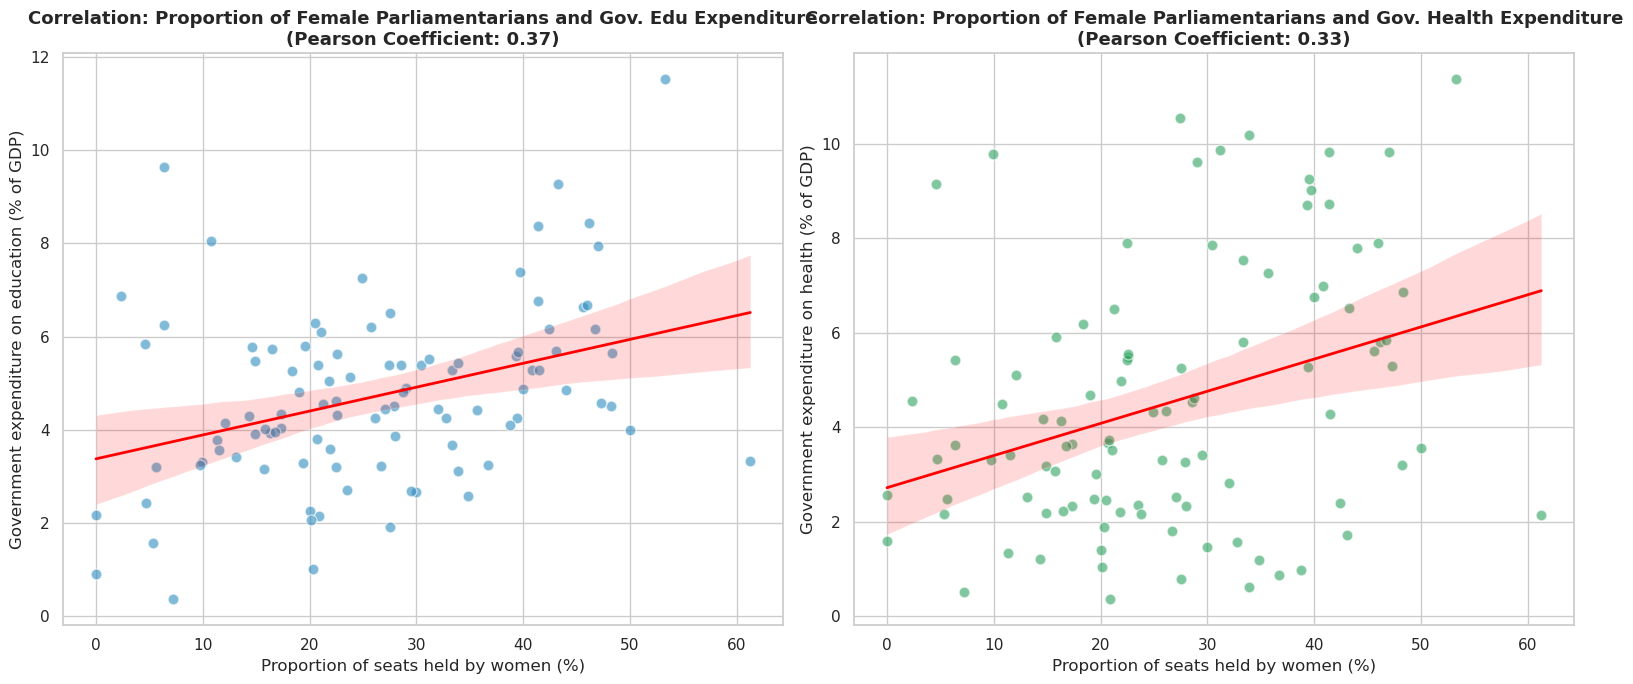

In [9]:
# === CHART 2: SCATTER PLOT & REGRESSION LINE ===
plt.figure(figsize=(16, 7))

# Calculate Pearson correlation coefficient
corr_edu = corr_clean['Women_in_Parliament'].corr(corr_clean['Edu_Expenditure'])
corr_health = corr_clean['Women_in_Parliament'].corr(corr_clean['Health_Expenditure'])

# Plot 1: Correlation with Education
plt.subplot(1, 2, 1)
sns.regplot(data=corr_clean, x='Women_in_Parliament', y='Edu_Expenditure', 
            scatter_kws={'alpha':0.6, 'color':'#2b8cbe', 'edgecolor':'w', 's':60}, 
            line_kws={'color':'red', 'linewidth':2})
plt.title(f'Correlation: Proportion of Female Parliamentarians and Gov. Edu Expenditure\n(Pearson Coefficient: {corr_edu:.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Proportion of seats held by women (%)')
plt.ylabel('Government expenditure on education (% of GDP)')

# Plot 2: Correlation with Healthcare
plt.subplot(1, 2, 2)
sns.regplot(data=corr_clean, x='Women_in_Parliament', y='Health_Expenditure', 
            scatter_kws={'alpha':0.6, 'color':'#2ca25f', 'edgecolor':'w', 's':60}, 
            line_kws={'color':'red', 'linewidth':2})
plt.title(f'Correlation: Proportion of Female Parliamentarians and Gov. Health Expenditure\n(Pearson Coefficient: {corr_health:.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Proportion of seats held by women (%)')
plt.ylabel('Government expenditure on health (% of GDP)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_67252/2830745956.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=corr_clean, x='Women_Bin', y='Edu_Expenditure', palette='GnBu', showfliers=False)
/tmp/ipykernel_67252/2830745956.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=corr_clean, x='Women_Bin', y='Health_Expenditure', palette='YlGn', showfliers=False)


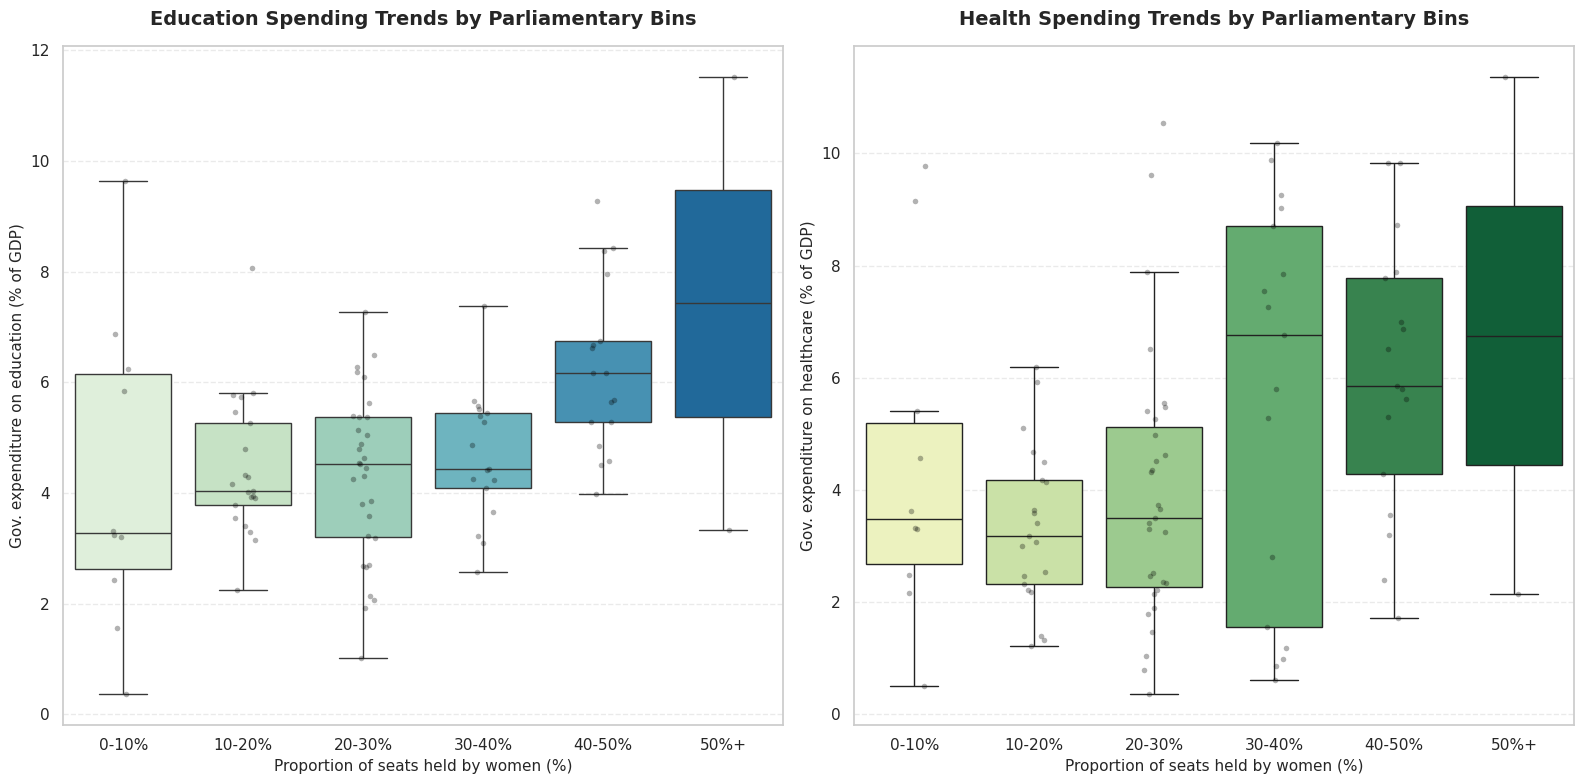

In [10]:
# === CHART 2.1: BINNED BOX PLOTS (DYNAMIZING CORRELATION) ===
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Binning 'Women_in_Parliament' into 10% ranges (0-10, 10-20, ..., 50%+)
bins = [0, 10, 20, 30, 40, 50, 100]
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+']
corr_clean['Women_Bin'] = pd.cut(corr_clean['Women_in_Parliament'], bins=bins, labels=labels)

plt.figure(figsize=(16, 8))

# Plot 1: Education Expenditure Distribution by Bin
plt.subplot(1, 2, 1)
sns.boxplot(data=corr_clean, x='Women_Bin', y='Edu_Expenditure', palette='GnBu', showfliers=False)
sns.stripplot(data=corr_clean, x='Women_Bin', y='Edu_Expenditure', color='black', alpha=0.3, size=4, jitter=True)
plt.title('Education Spending Trends by Parliamentary Bins', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Proportion of seats held by women (%)', fontsize=11)
plt.ylabel('Gov. expenditure on education (% of GDP)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Plot 2: Healthcare Expenditure Distribution by Bin
plt.subplot(1, 2, 2)
sns.boxplot(data=corr_clean, x='Women_Bin', y='Health_Expenditure', palette='YlGn', showfliers=False)
sns.stripplot(data=corr_clean, x='Women_Bin', y='Health_Expenditure', color='black', alpha=0.3, size=4, jitter=True)
plt.title('Health Spending Trends by Parliamentary Bins', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Proportion of seats held by women (%)', fontsize=11)
plt.ylabel('Gov. expenditure on healthcare (% of GDP)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Based on the 2 scatter plots and regression lines (red) above, our group extracts the following analysis:
* Both plots feature an upward-sloping trendline, and the Pearson coefficients are positive (0.37 and 0.33, respectively), meaning **a positive correlation trend exists**. This initially reinforces the hypothesis: *The higher the proportion of women holding seats in Parliament/National Assembly, the higher the tendency for the national budget allocation (% of GDP) towards social welfare (education and health) to increase.*
* However, **the correlation strength is only at a moderately weak level and has high dispersion**; the data dots (representing countries) are scattered widely across the entire graph space. The confidence interval (pink area) is quite wide, indicating a large variance between countries.
* Comparing the 2 sectors:
    * For **education**: **The correlation is slightly stronger** (Pearson coefficient reaches 0.37). The data tends to cluster more clearly in the middle area (female parliamentary rate of 20-40% corresponding with education spending of 4-6% of GDP).
    * For **healthcare**: **The correlation is weaker** (Pearson coefficient reaches 0.33) and contains many outliers breaking the rule. Specifically, there are countries with very low female representation (under 10%) but massive health budgets (reaching 8-10% of GDP); conversely, many countries have female representation at 20-40%, yet health spending is sluggishly under 2-4% of GDP.
